In [1]:
import itertools
import multiprocessing as mp
import os
import threading

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from tqdm.auto import tqdm

from polysim import OUTPUTS

/mnt/md0/jjusuf/miniconda3/envs/polysim3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- chain and LEFs ---
num_regions = 35
region_size = 2000
region_starts = np.arange(num_regions) * region_size  # the first index of each repeat
npoly = num_regions * region_size                     # number of monomers in entire chain monomers
sep = 240              # monomers per LEF -> nlefs = npoly // sep

# --- schedule ---
initsteps = 2_000_000  # equilibration steps, discarded
numsave = 7200         # recorded frames
saveevery = 3000       # LEF steps between frames

# --- swept parameters ---
vlef_values = [0.00125, 0.0025, 0.005, 0.01]       # p(step per leg per timestep)
stall_values = [0.125, 0.25, 0.5, 0.8]             # stall probability per encounter
life_values = [37000, 75000, 150000]               # LEF lifetime, in LEF timesteps
lifebooststalled_values = [1, 2, 4, 8]             # lifetime multiplier while stalled at a CTCF

# --- sweep execution ---
outroot = OUTPUTS / "sweep1D"
nworkers = 12

In [3]:
def config_name(sep, life, vlef, stall, lifebooststalled, saveevery):
    """Directory name encoding the parameters that distinguish one run from another."""
    return (
        "sep{0:g}_life{1:g}_vlef{2:g}_stall{3:g}"
        "_lifebooststalled{4:g}_saveevery{5:g}"
    ).format(sep, life, vlef, stall, lifebooststalled, saveevery)


ctcf_left = [200, 330, 724, 1425, 1433, 1604]  # right-facing
ctcf_right = [574, 694, 866, 1241, 1390, 1580, 1752, 1800]  # left-facing
convergent_ctcf_pairs = []
for pos1 in ctcf_left:
    for pos2 in ctcf_right:
        if pos1 < pos2:
            convergent_ctcf_pairs.append((pos1, pos2))
print(f'Identified {len(convergent_ctcf_pairs)} convergent CTCF pairs per region')

# Only the CTCF monomers are ever queried, so carry labels for those columns alone
# instead of for all region_size monomers.
ctcf_sites = sorted(set(ctcf_left) | set(ctcf_right))
site_index = np.full(region_size, -1, dtype=np.int64)   # monomer -> column, -1 = not a site
site_index[ctcf_sites] = np.arange(len(ctcf_sites))
pair_columns = [(ctcf_sites.index(pos1), ctcf_sites.index(pos2))
                for pos1, pos2 in convergent_ctcf_pairs]

Identified 30 convergent CTCF pairs per region


In [4]:
# Two LEFs are linked when any leg of one sits within `link_dist` monomers of any leg
# of the other -- exactly what the old in_contact() tested by intersecting the
# {pos-1, pos, pos+1} neighbourhood of every leg against every other. Two CTCF
# monomers are in contact when both are occupied by a leg and those two LEFs land in
# the same connected component of that relation.
#
# The old code rebuilt an N x N transitive closure for every (pair, region, block).
# Instead, label every LEF once per config: shift each block and each region into its
# own slice of a synthetic coordinate, separated by more than link_dist so nothing
# links across them, and the whole trajectory becomes one sort plus one
# connected_components call. On a line, linking only consecutive sorted legs already
# closes over every pair within link_dist, so no pairwise comparison is needed.

link_dist = 2                                        # max leg separation that links two LEFs
region_pad = region_size + 4 * link_dist
block_pad = num_regions * region_pad + 4 * link_dist


def label_lefs(lef_positions):
    """Connected-component label for every (block, LEF).

    Returns the labels plus the per-leg region / local-coordinate arrays, and the mask
    of LEFs that sit entirely inside one region (the others are dropped, matching the
    original per-region filter).
    """
    nblocks, nlefs, _ = lef_positions.shape

    region = lef_positions // region_size
    local = lef_positions - region * region_size
    inside = region[:, :, 0] == region[:, :, 1]      # drop LEFs straddling a boundary

    blocks = np.arange(nblocks)[:, None, None]
    coord = blocks * block_pad + region * region_pad + local
    node = np.arange(nblocks)[:, None] * nlefs + np.arange(nlefs)[None, :]

    keep = np.repeat(inside[:, :, None], 2, axis=2).ravel()
    coord = coord.ravel()[keep]
    owner = np.repeat(node[:, :, None], 2, axis=2).ravel()[keep]

    order = np.argsort(coord, kind='stable')
    coord, owner = coord[order], owner[order]
    linked = np.diff(coord) <= link_dist
    src, dst = owner[:-1][linked], owner[1:][linked]

    n_nodes = nblocks * nlefs
    graph = coo_matrix((np.ones(src.size, dtype=np.int8), (src, dst)),
                       shape=(n_nodes, n_nodes))
    _, labels = connected_components(graph, directed=False)
    return labels.reshape(nblocks, nlefs), inside, region, local


def site_labels(lef_positions):
    """Component label sitting on each CTCF monomer: (num_blocks, num_regions, n_sites).

    -1 means no LEF leg occupies that monomer in that block, so it cannot be looped.
    """
    nblocks = lef_positions.shape[0]
    labels, inside, region, local = label_lefs(lef_positions)

    column = site_index[local]                       # -1 for legs off a CTCF monomer
    sel = np.repeat(inside[:, :, None], 2, axis=2) & (column >= 0)

    at_site = np.full((nblocks, num_regions, len(ctcf_sites)), -1, dtype=labels.dtype)
    blocks = np.broadcast_to(np.arange(nblocks)[:, None, None], column.shape)
    per_leg = np.broadcast_to(labels[:, :, None], column.shape)
    at_site[blocks[sel], region[sel], column[sel]] = per_leg[sel]
    return at_site


def contact_matrix(at_site, col1, col2):
    """Boolean (num_blocks, num_repeats): is this CTCF pair looped in that block/region?"""
    a = at_site[:, :, col1]
    b = at_site[:, :, col2]
    return (a >= 0) & (a == b)

In [5]:
def loop_probability(contact):
    """Fraction of blocks in contact, averaged within each region then over regions."""
    return float(contact.mean(axis=0).mean())


def contact_durations(contact):
    """Lengths of the runs of consecutive in-contact blocks, with censoring flags.

    Walks the time axis of each region independently and returns one entry per
    contiguous stretch of contact. A run touching either end of the trajectory is
    censored: its recorded length is only a lower bound on the true loop lifetime,
    because the loop was already there when recording started, or still there when it
    stopped. Durations are in blocks; multiply by saveevery for LEF steps.
    """
    nblocks, nreg = contact.shape
    edge = np.zeros((1, nreg), dtype=bool)
    change = np.diff(np.vstack([edge, contact, edge]).astype(np.int8), axis=0)

    starts = np.argwhere(change == 1)                # (block, region) where a run opens
    ends = np.argwhere(change == -1)                 # (block, region) one past its close
    starts = starts[np.lexsort((starts[:, 0], starts[:, 1]))]
    ends = ends[np.lexsort((ends[:, 0], ends[:, 1]))]

    durations = ends[:, 0] - starts[:, 0]
    censored = (starts[:, 0] == 0) | (ends[:, 0] == nblocks)
    return durations, censored


def kaplan_meier(durations, censored):
    """Kaplan-Meier survival curve S(t) for the observed loop durations.

    S(t) = prod over event times t_j <= t of (1 - d_j / n_j), with n_j the number of
    loops still intact just before t_j and d_j the number that broke at t_j. Censored
    runs count towards n_j up to their own duration and then drop out, so they inform
    the curve without being treated as breakages.
    """
    durations = np.asarray(durations, dtype=float)
    if durations.size == 0:
        return np.empty(0), np.empty(0)

    observed = ~np.asarray(censored, dtype=bool)
    times = np.unique(durations)
    at_risk = durations.size - np.searchsorted(np.sort(durations), times, side='left')
    n_events = np.bincount(np.searchsorted(times, durations[observed]),
                           minlength=times.size)
    return times, np.cumprod(1.0 - n_events / at_risk)


def median_lifetime(durations, censored):
    """Median loop lifetime in blocks: the first time S(t) falls to 0.5 or below.

    NaN when the curve never gets there -- more than half the loops outlast the
    recording, so the median is not identified by this trajectory.
    """
    times, surv = kaplan_meier(durations, censored)
    reached = np.nonzero(surv <= 0.5)[0]
    return float(times[reached[0]]) if reached.size else np.nan

In [6]:
# Progress is reported at every step of the nested loop -- one tick for loading a
# config, one for labelling it, then one per CTCF pair -- so the bar tracks the whole
# task rather than jumping once per config. Workers push ticks down a queue that a
# listener thread in this process drains into the bar.

steps_per_config = 2 + len(convergent_ctcf_pairs)
_progress = None


def _init_worker(queue):
    global _progress
    _progress = queue


def _tick():
    if _progress is not None:
        _progress.put(1)


def analyse_config(config):
    """One config end to end: label once, then read every CTCF pair off those labels."""
    vlef, stall, life, lifebooststalled = config
    name = config_name(sep, life, vlef, stall, lifebooststalled, saveevery)

    lef_positions = np.load(os.path.join(outroot, name, 'LEFpositions.npy'))
    _tick()
    at_site = site_labels(lef_positions)
    _tick()

    rows = []
    for (pos1, pos2), (col1, col2) in zip(convergent_ctcf_pairs, pair_columns):
        contact = contact_matrix(at_site, col1, col2)
        durations, censored = contact_durations(contact)
        median = median_lifetime(durations, censored)
        rows.append({
            'vlef': vlef, 'stall': stall, 'life': life,
            'lifebooststalled': lifebooststalled,
            'pos1': pos1, 'pos2': pos2,
            'loop_prob': loop_probability(contact),
            'median_lifetime_blocks': median,
            'median_lifetime_steps': median * saveevery,
            'n_loops': int(durations.size),
            'n_censored': int(censored.sum()),
        })
        _tick()
    return rows


def run_sweep(configs, nworkers=nworkers):
    # fork so the workers inherit these notebook-defined functions
    ctx = mp.get_context('fork')
    manager = ctx.Manager()
    queue = manager.Queue()
    bar = tqdm(total=len(configs) * steps_per_config, unit='step', desc='analysing sweep')

    def drain():
        while True:
            tick = queue.get()
            if tick is None:
                break
            bar.update(tick)

    listener = threading.Thread(target=drain, daemon=True)
    listener.start()
    try:
        with ctx.Pool(nworkers, initializer=_init_worker, initargs=(queue,)) as pool:
            rows = [row for chunk in pool.imap_unordered(analyse_config, configs)
                    for row in chunk]
    finally:
        queue.put(None)
        listener.join()
        bar.close()
        manager.shutdown()
    return pd.DataFrame(rows)

In [7]:
configs = list(itertools.product(
    vlef_values, stall_values, life_values, lifebooststalled_values))

results = run_sweep(configs)
results.to_csv(outroot / 'gt_loop_stats.csv', index=False)
print(f'{len(results)} rows = {len(configs)} configs x {len(convergent_ctcf_pairs)} pairs'
      f'  ->  {outroot / "gt_loop_stats.csv"}')
results.head()

analysing sweep:   0%|          | 0/6144 [00:00<?, ?step/s]

analysing sweep: 100%|██████████| 6144/6144 [00:06<00:00, 985.60step/s] 

5760 rows = 192 configs x 30 pairs  ->  /mnt/md1/jjusuf/polysim/outputs/sweep1D/gt_loop_stats.csv


,vlef,stall,life,lifebooststalled,pos1,pos2,loop_prob,median_lifetime_blocks,median_lifetime_steps,n_loops,n_censored
0,0.00125,0.125,37000,1,200,574,0.000060,1.0,3000.0,5,0
1,0.00125,0.125,37000,1,200,694,0.000016,4.0,12000.0,1,0
2,0.00125,0.125,37000,1,200,866,0.000000,NaN,NaN,0,0
3,0.00125,0.125,37000,1,200,1241,0.000000,NaN,NaN,0,0
4,0.00125,0.125,37000,1,200,1390,0.000000,NaN,NaN,0,0


In [8]:
# Ground truth per config, pooled over the 30 convergent pairs.
summary = (results
           .groupby(['vlef', 'stall', 'life', 'lifebooststalled'], as_index=False)
           .agg(loop_prob=('loop_prob', 'mean'),
                median_lifetime_blocks=('median_lifetime_blocks', 'median'),
                pairs_without_median=('median_lifetime_blocks',
                                      lambda s: int(s.isna().sum()))))
summary.sort_values('loop_prob', ascending=False).head(10)

,vlef,stall,life,lifebooststalled,loop_prob,median_lifetime_blocks,pairs_without_median
191,0.0100,0.8,150000,8,0.157451,23.0,0
187,0.0100,0.8,75000,8,0.147401,12.5,0
143,0.0050,0.8,150000,8,0.146304,25.0,0
190,0.0100,0.8,150000,4,0.143621,22.5,0
179,0.0100,0.5,150000,8,0.137881,25.0,0
95,0.0025,0.8,150000,8,0.133432,23.0,0
186,0.0100,0.8,75000,4,0.132951,11.5,0
142,0.0050,0.8,150000,4,0.132349,21.0,0
139,0.0050,0.8,75000,8,0.131954,12.0,0
183,0.0100,0.8,37000,8,0.131754,6.0,0


# Plots

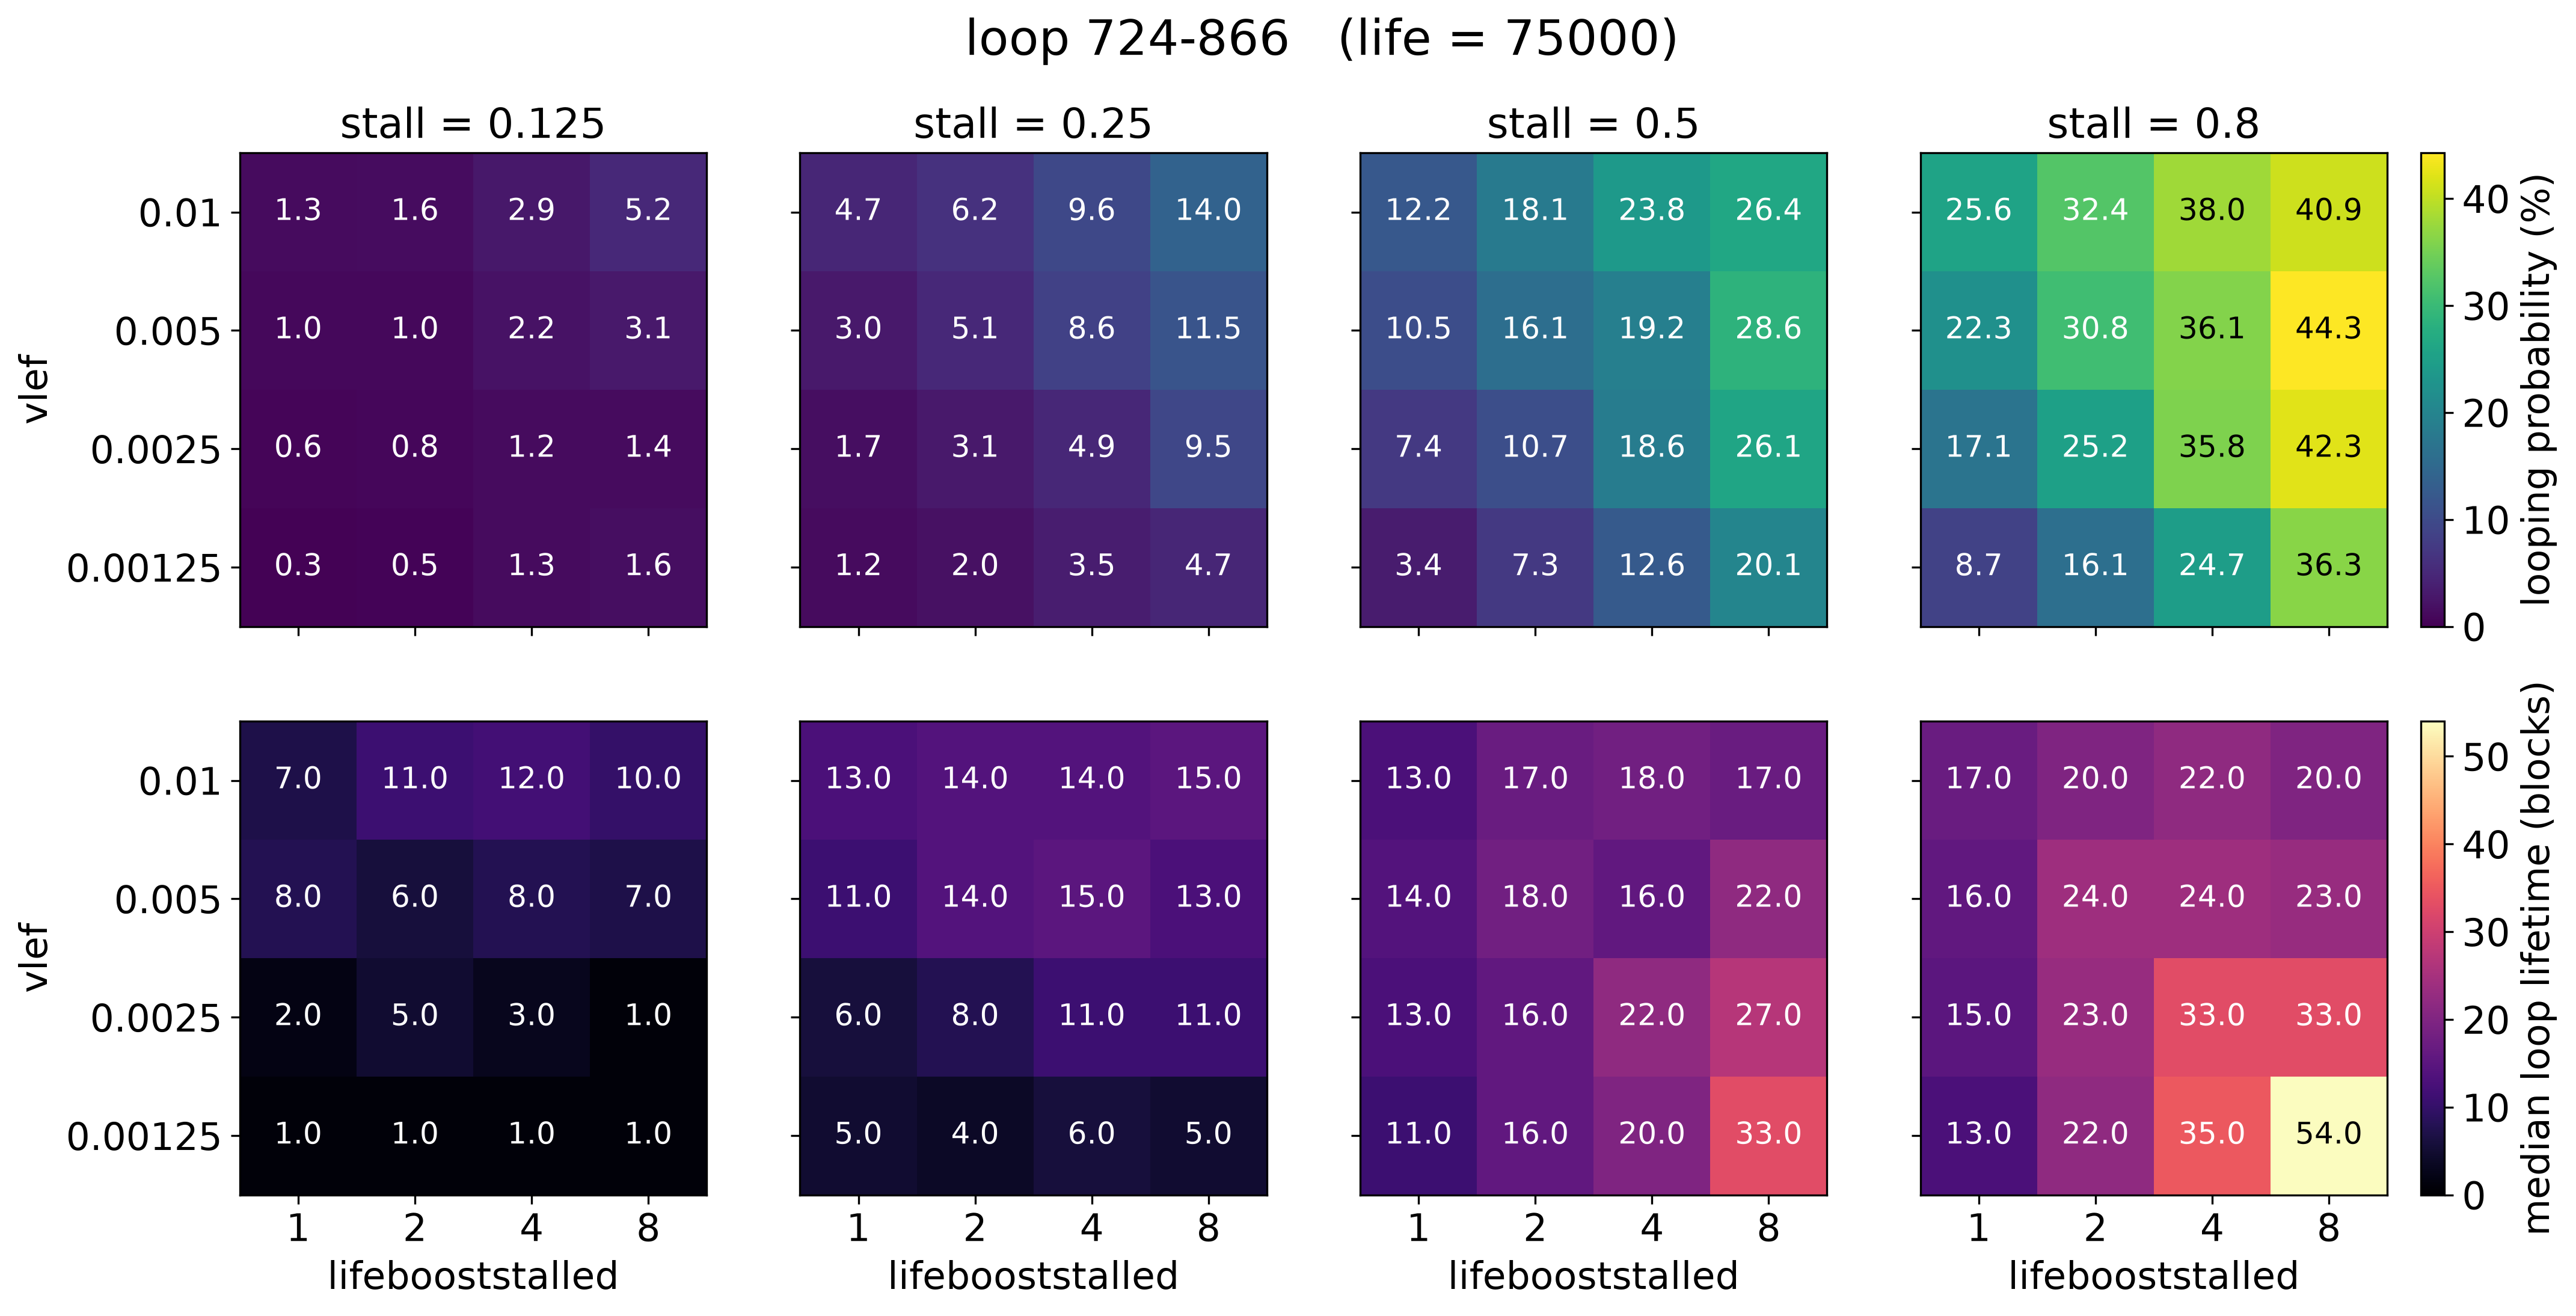

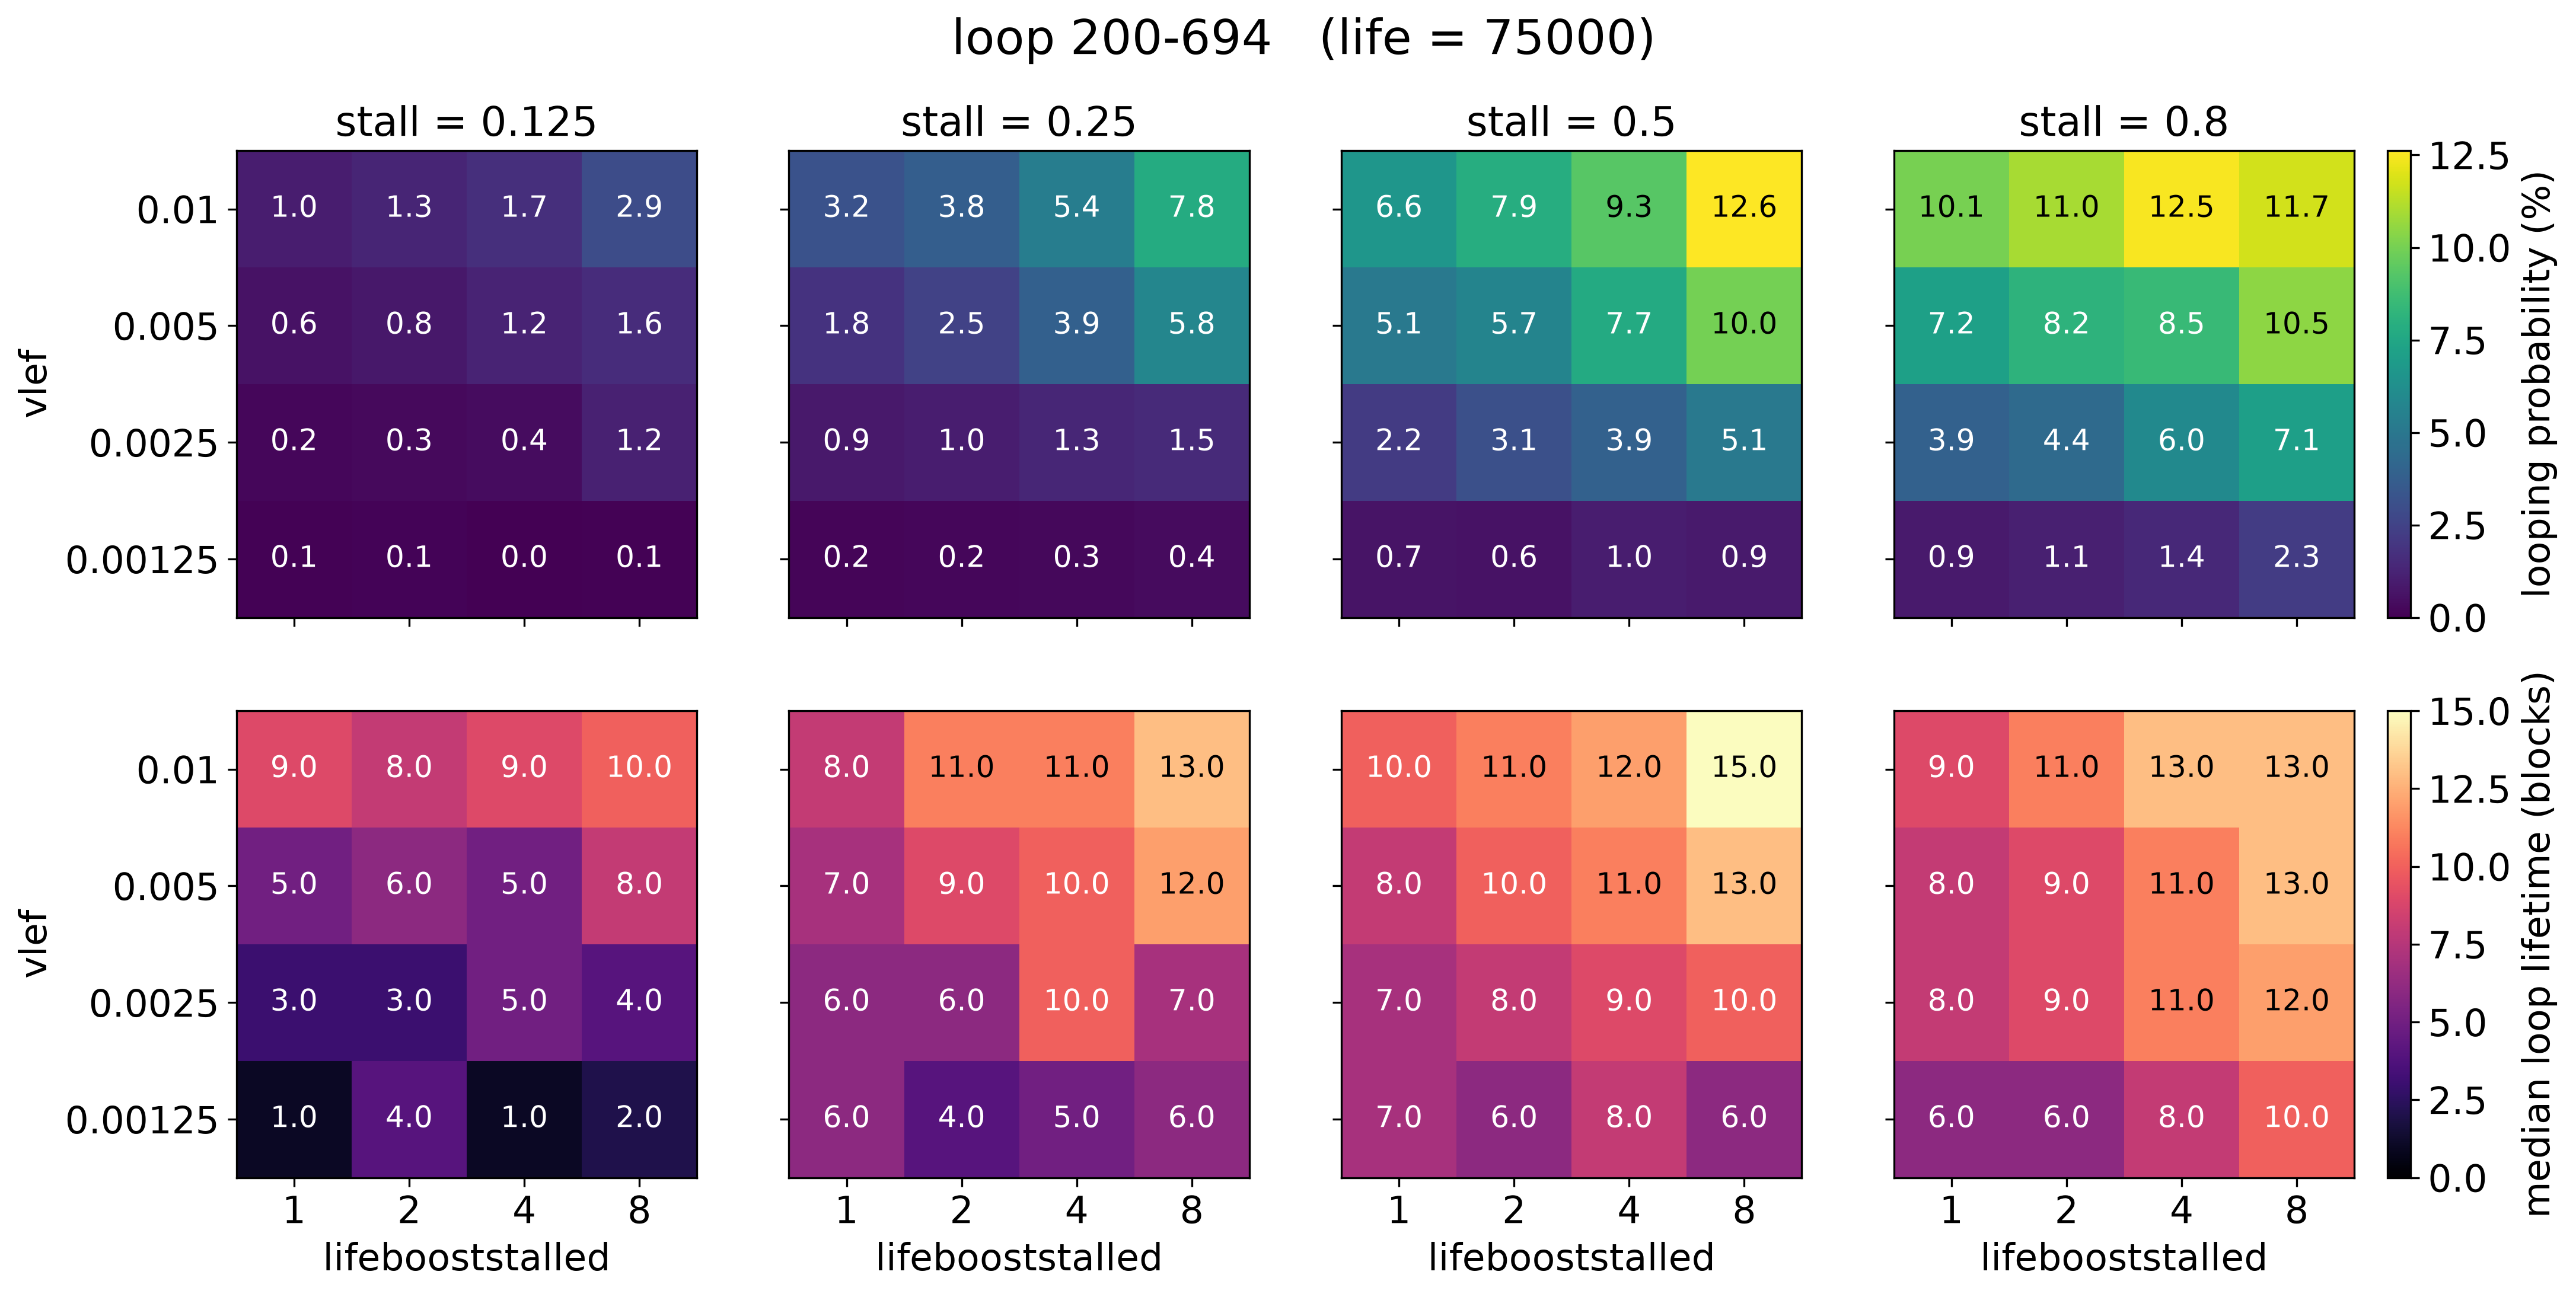

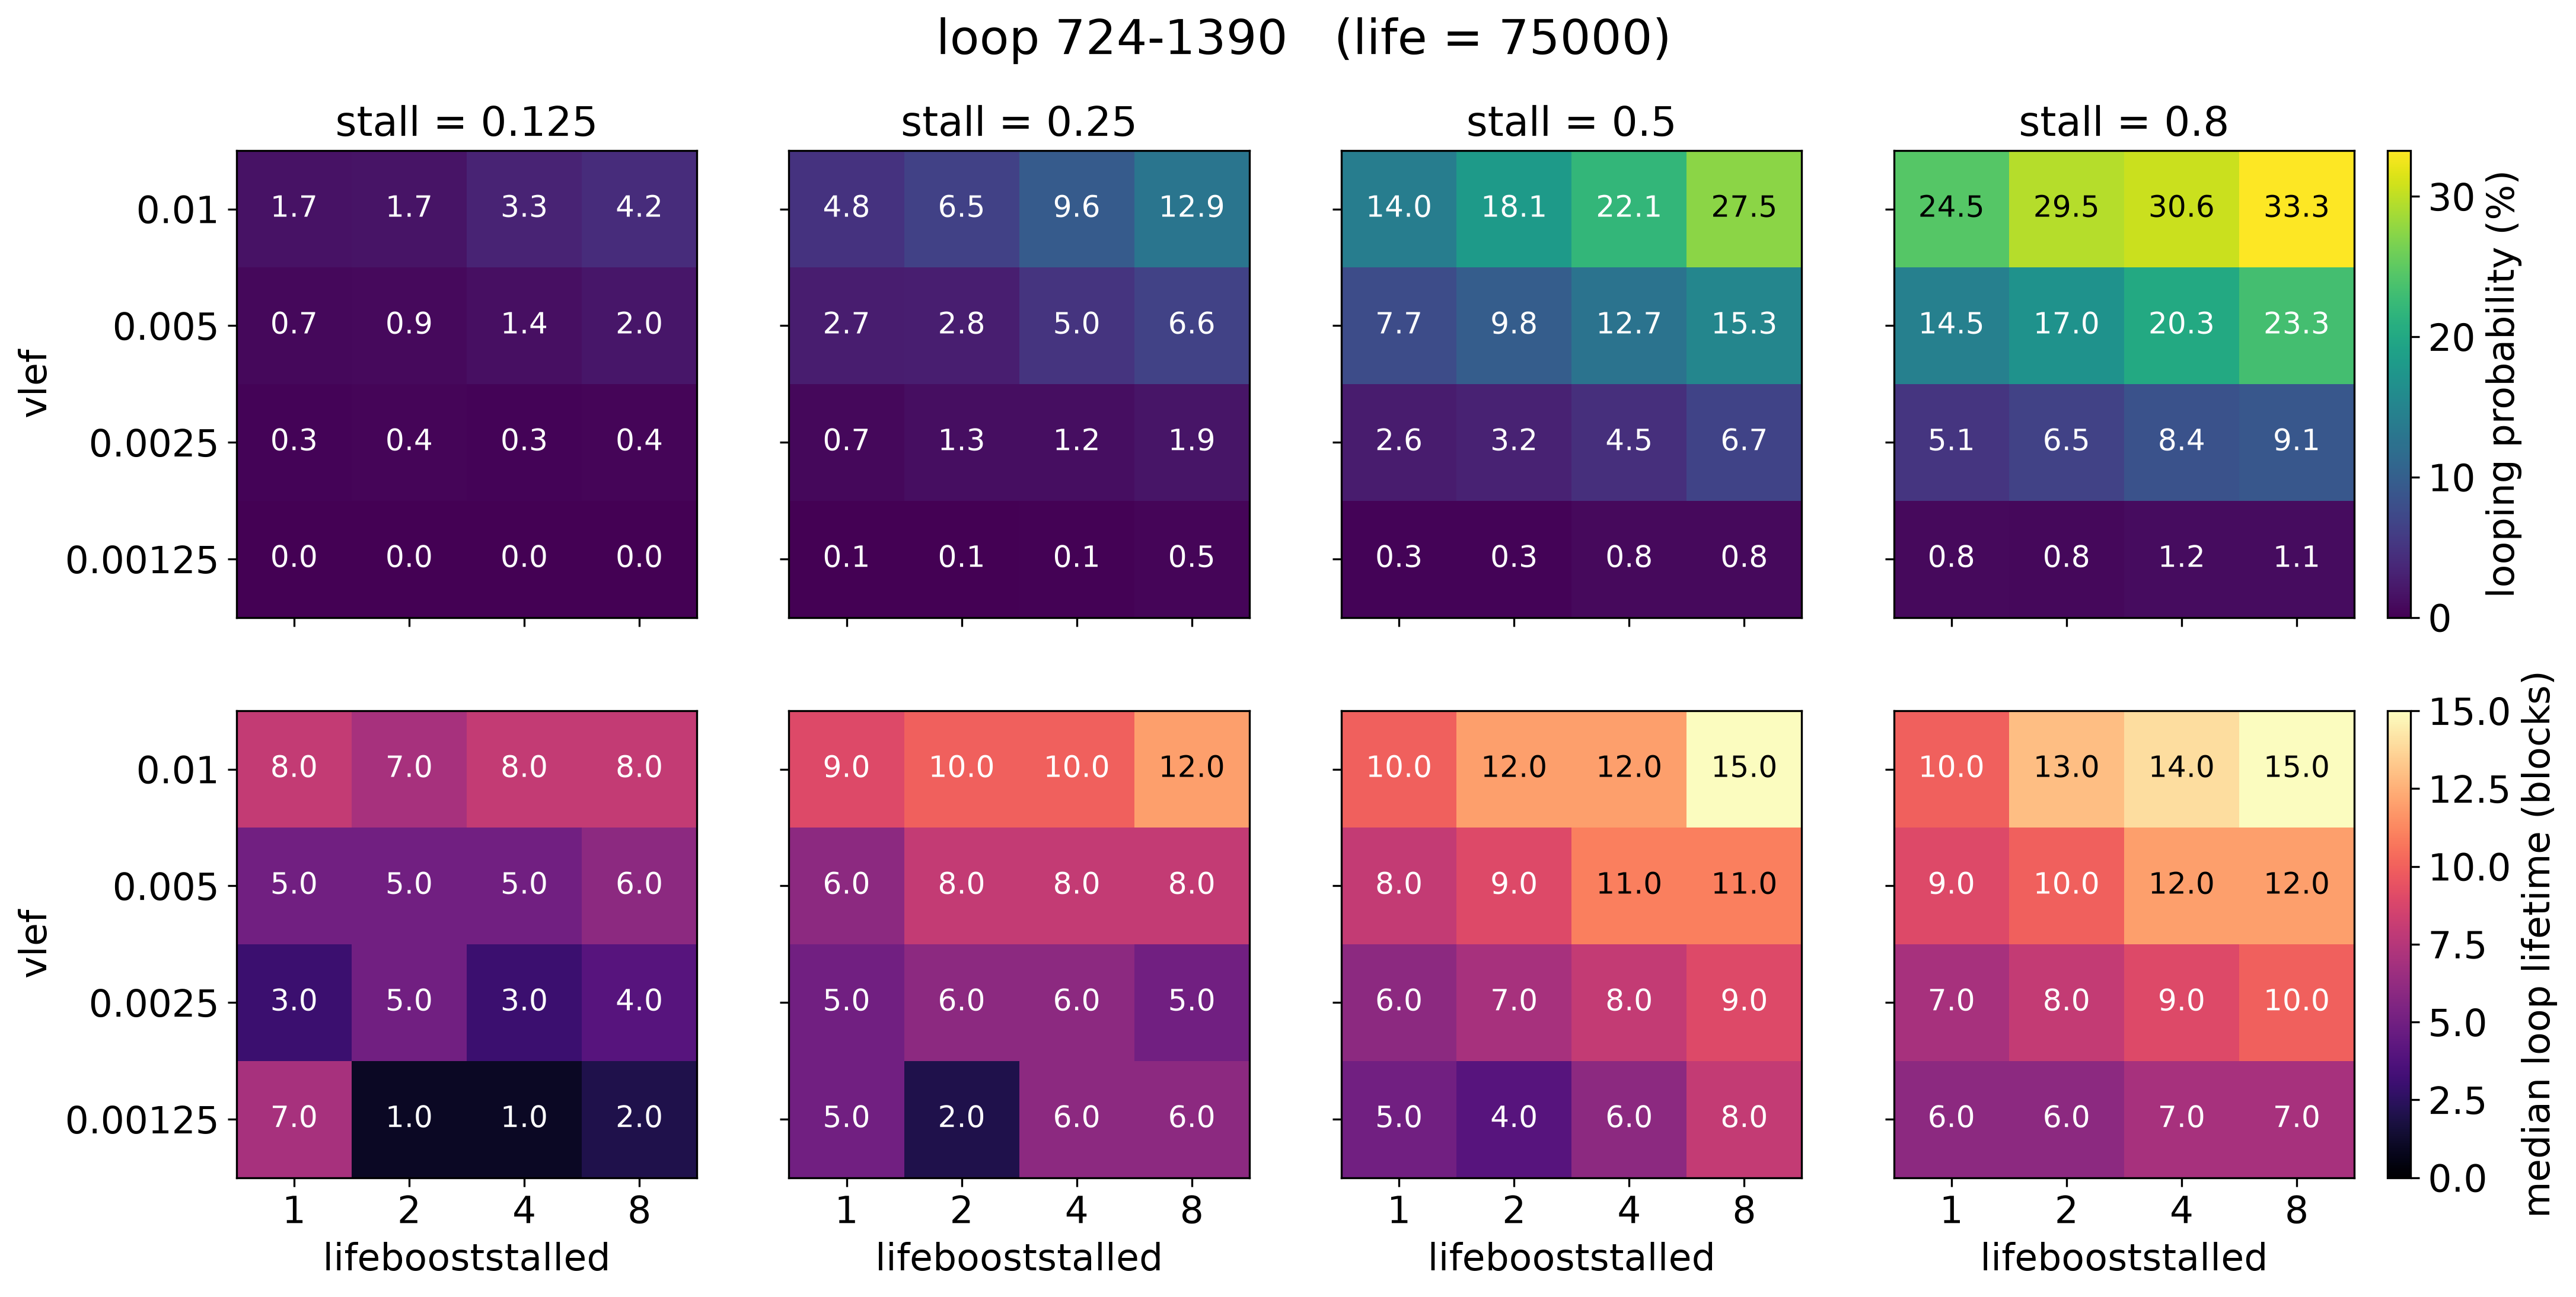

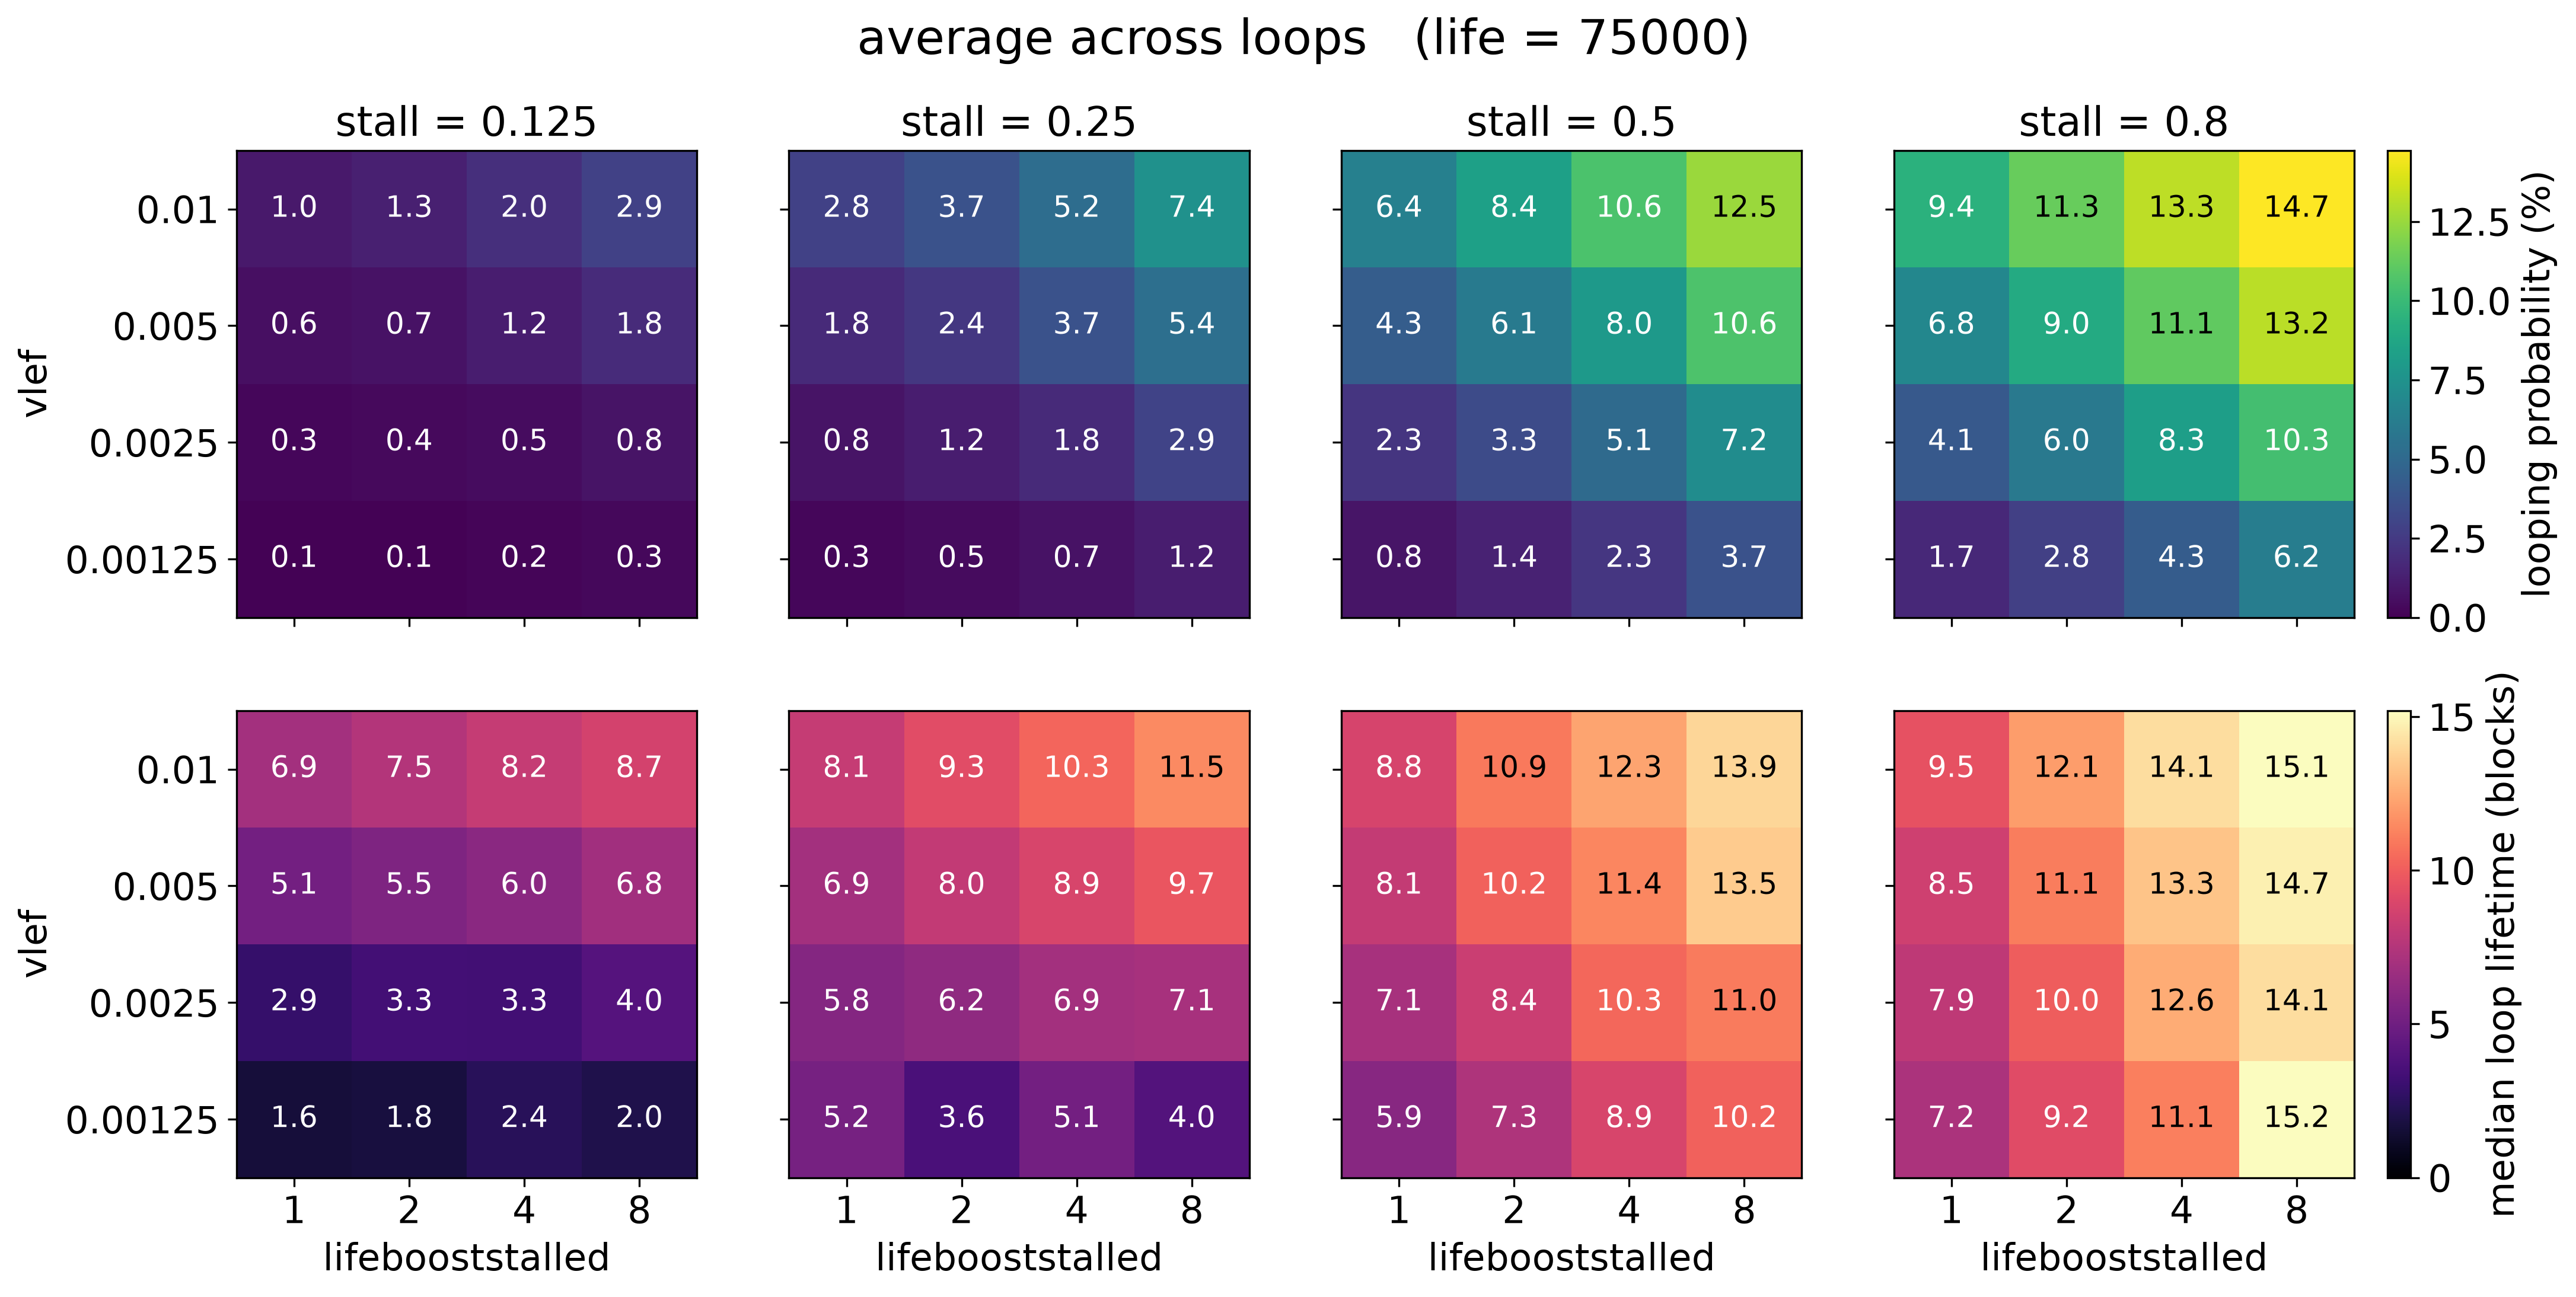

In [11]:
# Ground truth as a function of vlef and lifebooststalled at fixed LEF lifetime, for two
# named loops and for the average over all convergent pairs. Each quantity gets one
# colour scale per figure, shared by that figure's four stall panels so they can be read
# against each other; the scale is refit per figure because the loops span very
# different ranges. Every cell also carries its value.

fixed_life = 75000
fontscale = 1.5                                  # ~50% larger text
cell_fs, label_fs, title_fs = 8 * fontscale, 10 * fontscale, 13 * fontscale

at_life = results[results.life == fixed_life]

targets = [
    ('loop 724-866', at_life[(at_life.pos1 == 724) & (at_life.pos2 == 866)]),
    ('loop 200-694', at_life[(at_life.pos1 == 200) & (at_life.pos2 == 694)]),
    ('loop 724-1390', at_life[(at_life.pos1 == 724) & (at_life.pos2 == 1390)]),
    ('average across loops', at_life),
]
quantities = [   # label, column, colormap, cell format, scale applied to the values
    ('looping probability (%)', 'loop_prob', 'viridis', '{:.1f}', 100.0),
    ('median loop lifetime (blocks)', 'median_lifetime_blocks', 'magma', '{:.1f}', 1.0),
]


def heat_grid(frame, column, stall):
    """4x4 array of `column` over (vlef, lifebooststalled) at one stall value.

    Averages whatever rows fall in each cell: a single value for one named loop, the
    mean over the 30 convergent pairs for the average. NaN medians -- pairs that never
    loop, so no median is defined -- drop out of that mean.
    """
    table = frame[frame.stall == stall].pivot_table(
        index='vlef', columns='lifebooststalled', values=column, aggfunc='mean')
    return table.reindex(index=vlef_values, columns=lifebooststalled_values).to_numpy()


grids = {(name, column): [scale * heat_grid(frame, column, stall) for stall in stall_values]
         for name, frame in targets for _, column, _, _, scale in quantities}
limits = {(name, column): (0.0, float(np.nanmax(grids[name, column])))
          for name, _ in targets for _, column, _, _, _ in quantities}

for name, _ in targets:
    fig, axes = plt.subplots(2, 4, figsize=(16, 7.5), sharex=True, sharey=True, dpi=300)
    for row, (label, column, cmap_name, fmt, _) in enumerate(quantities):
        vmin, vmax = limits[name, column]
        cmap = plt.get_cmap(cmap_name).copy()
        cmap.set_bad('0.85')                        # no median defined for this cell
        for col, stall in enumerate(stall_values):
            ax = axes[row, col]
            grid = grids[name, column][col]
            im = ax.imshow(grid, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax,
                           aspect='auto', interpolation='nearest')
            for i, j in np.ndindex(grid.shape):
                if np.isfinite(grid[i, j]):
                    # ink from the luminance of the colour imshow actually drew
                    red, green, blue, _ = im.cmap(im.norm(grid[i, j]))
                    ink = 'k' if 0.299 * red + 0.587 * green + 0.114 * blue > 0.6 else 'w'
                    ax.text(j, i, fmt.format(grid[i, j]), ha='center', va='center',
                            fontsize=cell_fs, color=ink)
            ax.tick_params(labelsize=label_fs)
            if row == 0:
                ax.set_title(f'stall = {stall:g}', fontsize=label_fs * 1.1)
            else:
                ax.set_xlabel('lifebooststalled', fontsize=label_fs)
            if col == 0:
                ax.set_ylabel('vlef', fontsize=label_fs)
        bar = fig.colorbar(im, ax=axes[row, :].tolist(), fraction=0.025, pad=0.015)
        bar.set_label(label, fontsize=label_fs)
        bar.ax.tick_params(labelsize=label_fs)

    axes[0, 0].set_xticks(range(len(lifebooststalled_values)), lifebooststalled_values)
    axes[0, 0].set_yticks(range(len(vlef_values)), [f'{v:g}' for v in vlef_values])
    fig.suptitle(f'{name}   (life = {fixed_life:g})', fontsize=title_fs)